In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

In [63]:
df=pd.read_excel("fold.xlsx")

In [64]:
df.head()

,date_added,week,category,show_title,season_title,weekly_rank,cumulative_weeks_in_top_10,weekly_hours_viewed,Imdb_rating
0,2022-05-10,2022-05-08,Films (English),365 Days,NaN,10,2,6290000,NaN
1,2022-04-26,2022-04-24,TV (Non-English),Heirs to the Land,Heirs to the Land: Season 1,5,2,18840000,7.3
2,2022-05-03,2022-05-01,Films (English),365 Days,NaN,4,1,10040000,5.3
3,2022-05-03,2022-05-01,Films (English),365 Days: This Day,NaN,1,1,77980000,7.0
4,2022-04-12,2022-04-10,Films (Non-English),Furioza,NaN,1,1,23960000,7.4


In [65]:
df.columns

Index(['date_added', 'week', 'category', 'show_title', 'season_title',
       'weekly_rank', 'cumulative_weeks_in_top_10', 'weekly_hours_viewed',
       'Imdb_rating'],
      dtype='object')

In [66]:
df.isna().sum()

date_added                      0
week                            0
category                        0
show_title                      0
season_title                  271
weekly_rank                     0
cumulative_weeks_in_top_10      0
weekly_hours_viewed             0
Imdb_rating                     1
dtype: int64

In [67]:
df=df.dropna(subset=["season_title","Imdb_rating"])

In [68]:
df.head()

,date_added,week,category,show_title,season_title,weekly_rank,cumulative_weeks_in_top_10,weekly_hours_viewed,Imdb_rating
1,2022-04-26,2022-04-24,TV (Non-English),Heirs to the Land,Heirs to the Land: Season 1,5,2,18840000,7.3
10,2022-04-12,2022-04-10,TV (Non-English),"Yo soy Betty, la fea","Yo soy Betty, la fea: Season 1",6,18,10590000,4.2
12,2022-05-10,2022-05-08,TV (Non-English),Our Blues,Our Blues: Season 1,6,2,10370000,6.3
17,2022-06-14,2022-06-12,TV (Non-English),Wrong Side of the Tracks,Wrong Side of the Tracks: Season 1,1,4,19400000,5.9
19,2022-04-26,2022-04-24,TV (Non-English),The Marked Heart,The Marked Heart: Season 1,1,1,68040000,7.8


In [69]:
df.isna().sum()

date_added                    0
week                          0
category                      0
show_title                    0
season_title                  0
weekly_rank                   0
cumulative_weeks_in_top_10    0
weekly_hours_viewed           0
Imdb_rating                   0
dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

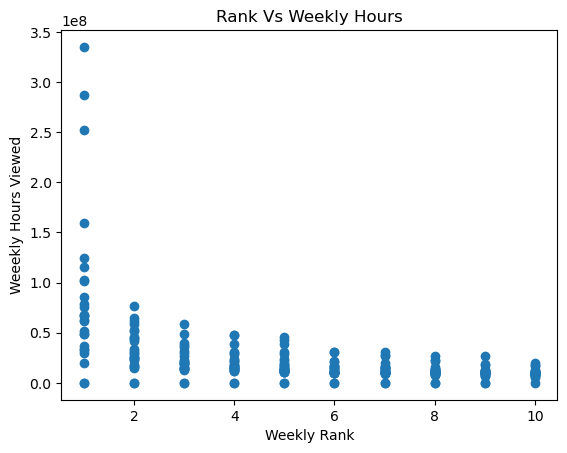

In [70]:
plt.figure
plt.scatter(df['weekly_rank'], df['weekly_hours_viewed'])
plt.xlabel("Weekly Rank")
plt.ylabel("Weeekly Hours Viewed")
plt.title("Rank Vs Weekly Hours")
plt.show

In [71]:
df[['Imdb_rating', 'weekly_rank', 
    'weekly_hours_viewed', 
    'cumulative_weeks_in_top_10']].corr()

,Imdb_rating,weekly_rank,weekly_hours_viewed,cumulative_weeks_in_top_10
Imdb_rating,1.000000,-0.060750,0.045932,-0.034668
weekly_rank,-0.060750,1.000000,-0.472244,0.154196
weekly_hours_viewed,0.045932,-0.472244,1.000000,-0.147321
cumulative_weeks_in_top_10,-0.034668,0.154196,-0.147321,1.000000


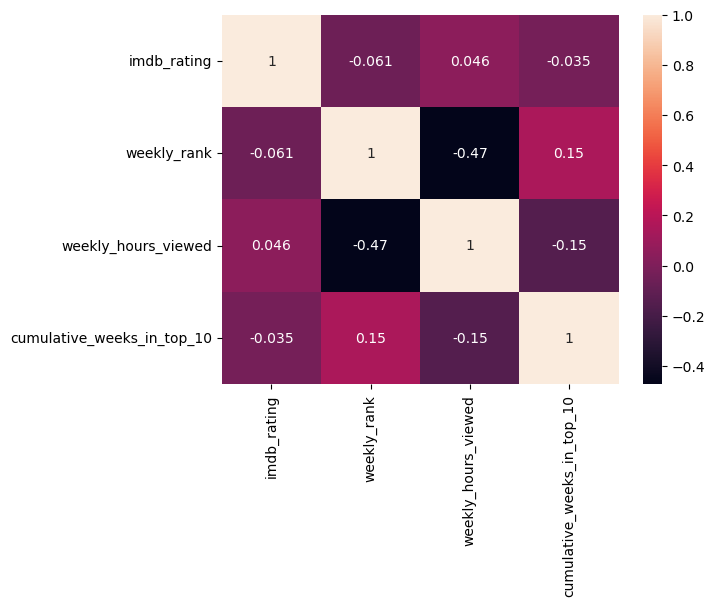

In [73]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

corr=df[['imdb_rating', 'weekly_rank', 
    'weekly_hours_viewed', 
    'cumulative_weeks_in_top_10']].corr()
sns.heatmap(corr,annot=True)
plt.show()

In [48]:
pip install rapidfuzz

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
    --------------------------------------- 0.0/1.5 MB 187.9 kB/s eta 0:00:09
    --------------------------------------- 0.0/1.5 MB 187.9 kB/s eta 0:00:09
    --------------------------------------- 0.0/1.5 MB 187.9 kB/s eta 0:00:09
    --------------------------------------- 0.0/1.5 MB 187.9 kB/s eta 0:00:09
   - -------------------------------------- 0.0/1.5 MB 93.7 kB/s eta 0:00:16
   - -------------------------------------- 0.0/1.5 MB 93.7 kB/s eta 0:00:16
   - -------------------------------------- 0.1/1.5 MB 121.6 kB/s eta 0:00:13
   - -------------------------------------

In [59]:
import pandas as pd
import re
from rapidfuzz import process

nflx_df = pd.read_excel('fold.xlsx')
imdb_df = pd.read_excel('rating datasets.xlsx')

# Clean column names
nflx_df.columns = nflx_df.columns.str.strip()
imdb_df.columns = imdb_df.columns.str.strip()

# 🔥 CLEAN FUNCTION (VERY IMPORTANT)
def clean(x):
    if pd.isna(x):
        return ""
    x = str(x).lower()
    
    # remove season/volume/part
    x = re.sub(r':? season \d+', '', x)
    x = re.sub(r':? volume \d+', '', x)
    x = re.sub(r':? part \d+', '', x)
    x = re.sub(r':? limited series', '', x)
    
    # remove brackets
    x = re.sub(r'\(.*?\)', '', x)
    
    # remove special characters
    x = re.sub(r'[^a-z0-9 ]', ' ', x)
    
    # remove extra spaces
    x = re.sub(r'\s+', ' ', x).strip()
    
    return x

# Apply cleaning
nflx_df["clean"] = nflx_df["show_title"].apply(clean)
imdb_df["clean"] = imdb_df["title"].apply(clean)

# 🔥 FUZZY MATCHING (create mapping)
match_list = []

for title in nflx_df["clean"]:
    match = process.extractOne(title, imdb_df["clean"])
    
    if match and match[1] >= 85:
        match_list.append(match[0])
    else:
        match_list.append(None)

nflx_df["matched_title"] = match_list

# 🔥 MERGE (THIS KEEPS 521 ROWS)
final_df = pd.merge(
    nflx_df,
    imdb_df,
    left_on="matched_title",
    right_on="clean",
    how="left"
)

# Replace missing ratings with 0
final_df["rating"] = final_df["rating"].fillna(0)

# Save final dataset
final_df.to_excel("FINAL_NETFLIX_IMDB_521.xlsx", index=False)

# Check rows
print("Final rows:", len(final_df))

Final rows: 537


In [15]:
import pandas as pd

# Excel file load karo
df = pd.read_excel("rating datasets.xlsx")

# Top 10 highest rated titles
top10 = df.sort_values(by='rating', ascending=False).head(10)

# Sirf show titles print karo
print(top10['title'])

11815                           NaN
12002                      Khawatir
1340                Planet Earth II
3922                            NaN
9419                   Planet Earth
13991                  Breaking Bad
2471     Avatar: The Last Airbender
6584                 Blue Planet II
15841                    Our Planet
13302      The Shawshank Redemption
Name: title, dtype: object


In [16]:
top10 = df.dropna(subset=['title']) \
          .sort_values(by='rating', ascending=False) \
          .head(10)

print(top10['title'].tolist())

['Planet Earth II', 'Khawatir', 'Breaking Bad', 'Planet Earth', 'Avatar: The Last Airbender', 'Blue Planet II', 'The Shawshank Redemption', 'Our Planet', 'Because I Love You', 'The Godfather']


In [17]:
import pandas as pd

# Excel file load karo
df = pd.read_excel("rating datasets.xlsx")

# Pura data print karo
print(df)

# Save karna ho to
df.to_excel("clean_full_dataset.xlsx", index=False)

                                                  title  rating
0                                       Bhool Bhulaiyaa     7.3
1                                              Trespass     5.3
2                                         Dancing Queen     7.0
3                                                   NaN     7.4
4      Trailer Park Boys: Say Goodnight to the Bad Guys     7.9
...                                                 ...     ...
15874                                         ヘルタースケルター     6.3
15875                                  Angel Has Fallen     6.4
15876              Paranormal Activity: The Marked Ones     5.0
15877               Sleepy Princess in the Demon Castle     7.5
15878                         Crayon Shin-chan Spin-off     8.3

[15879 rows x 2 columns]


In [19]:
df_sorted = df.sort_values(by='rating', ascending=False)

print(df_sorted)
df_clean = df.dropna()

print(df_clean)

                                              title  rating
11815                                           NaN     9.7
12002                                      Khawatir     9.5
1340                                Planet Earth II     9.5
3922                                            NaN     9.4
9419                                   Planet Earth     9.4
...                                             ...     ...
5601                                    The In-Laws     0.0
11160                                 Crazy Romance     0.0
601    Once in a Lifetime Sessions with OneRepublic     0.0
602            King of Boys: The Return of the King     0.0
2198                                     Queen Mimi     0.0

[15879 rows x 2 columns]
                                                  title  rating
0                                       Bhool Bhulaiyaa     7.3
1                                              Trespass     5.3
2                                         Dancing Queen     7.

<function matplotlib.pyplot.show(close=None, block=None)>

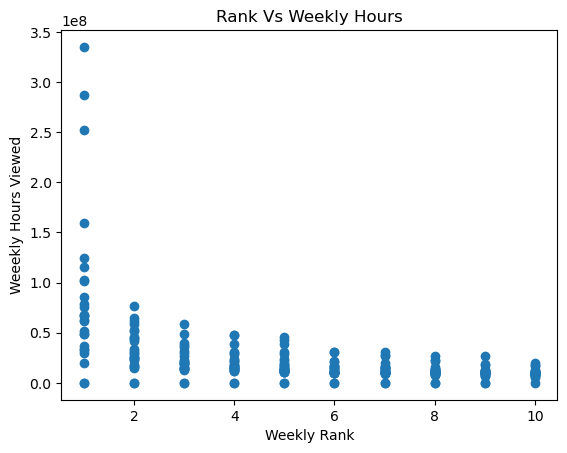

In [9]:
plt.figure
plt.scatter(df['weekly_rank'], df['weekly_hours_viewed'])
plt.xlabel("Weekly Rank")
plt.ylabel("Weeekly Hours Viewed")
plt.title("Rank Vs Weekly Hours")
plt.show

In [10]:
df[['Imdb_rating', 'weekly_rank', 
    'weekly_hours_viewed', 
    'cumulative_weeks_in_top_10']].corr()

,Imdb_rating,weekly_rank,weekly_hours_viewed,cumulative_weeks_in_top_10
Imdb_rating,1.000000,-0.060750,0.045932,-0.034668
weekly_rank,-0.060750,1.000000,-0.472244,0.154196
weekly_hours_viewed,0.045932,-0.472244,1.000000,-0.147321
cumulative_weeks_in_top_10,-0.034668,0.154196,-0.147321,1.000000


In [11]:
print(df.columns)

Index(['date_added', 'week', 'category', 'show_title', 'season_title',
       'weekly_rank', 'cumulative_weeks_in_top_10', 'weekly_hours_viewed',
       'Imdb_rating'],
      dtype='object')
